# Illustration of $k$-means clustering using NYC Taxi Zones

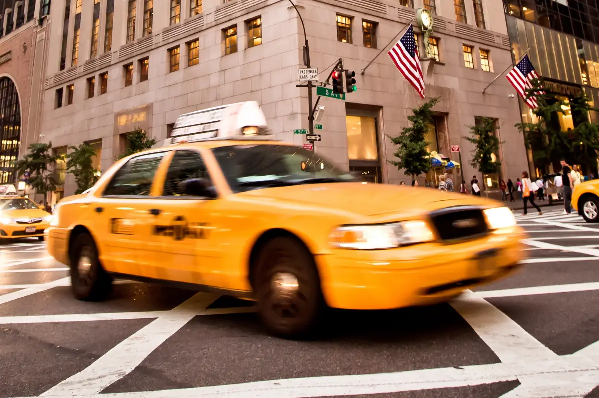

Copyright: New York Post

NYC TLC Trip Record Data

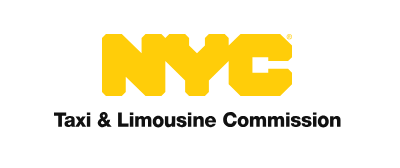

## Import and install requirements

In [66]:
!pip install datadepot

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datadepot


## Load the dataset

In [68]:
df = datadepot.load("nyc_taxi")

## Inspect the dataset

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   zone_id       260 non-null    int64  
 1   zone_name     260 non-null    object 
 2   trips         260 non-null    int64  
 3   med_distance  260 non-null    float64
 4   med_fare      260 non-null    float64
 5   med_tip       260 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 12.3+ KB


## Check for missing data

In [70]:
df.isna().sum()

,0
zone_id,0
zone_name,0
trips,0
med_distance,0
med_fare,0
med_tip,0


## Descriptive statistics

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
zone_id,260.0,132.303846,76.451186,1.00,65.75000,133.500,198.2500,263.00
trips,260.0,171094.207692,380160.890662,4.00,4554.50000,12160.500,64178.0000,2034449.00
med_distance,260.0,5.572865,3.246735,0.08,3.80000,4.865,7.0625,19.84
med_fare,260.0,26.120731,9.955530,4.36,21.54125,24.785,29.8950,71.60
med_tip,260.0,0.702808,1.705112,0.00,0.00000,0.000,0.0000,10.44


## Visualization using pairplot

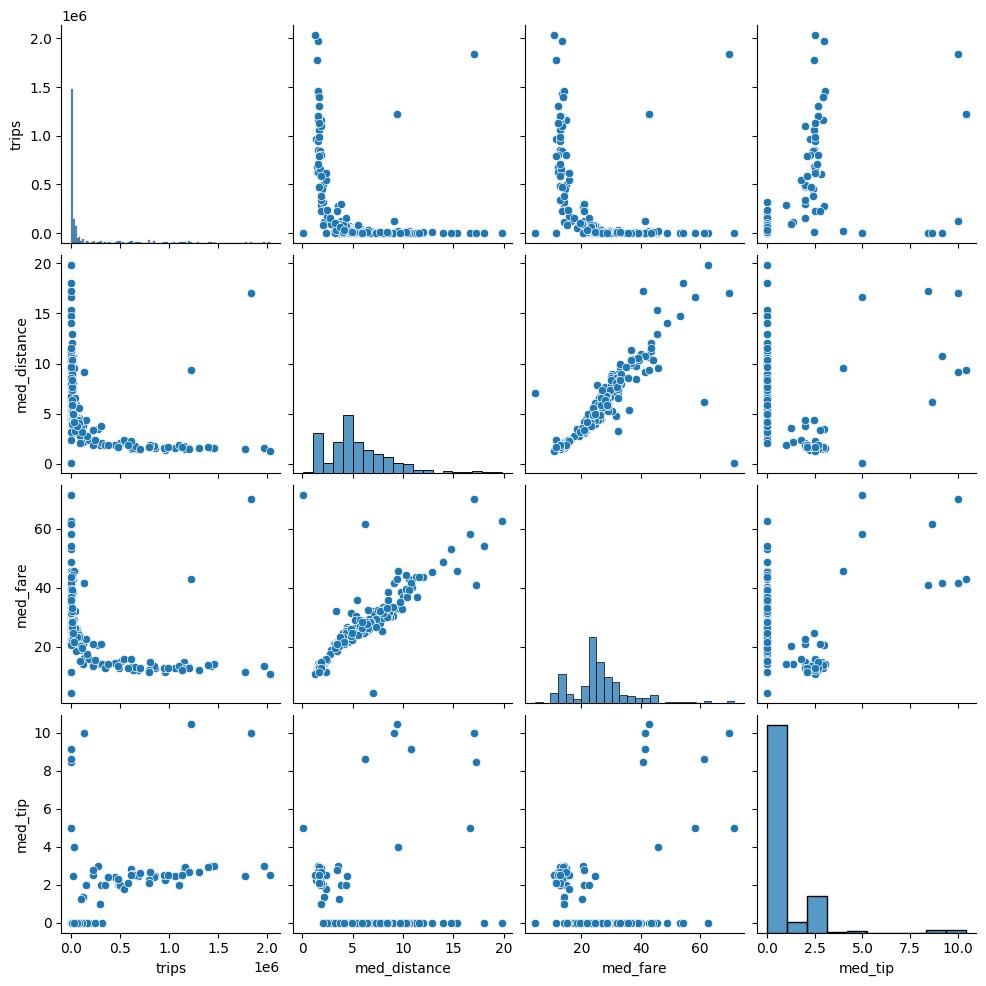

In [72]:
subset = ["trips", "med_distance", "med_fare", "med_tip"]
sns.pairplot(df[subset])

## Filter out taxi zones with few recorded trips

In [73]:
df = df.query("trips > 100")

## Transform the `trips` variable.

In [74]:
df["log_trips"] = np.log1p(df["trips"])

## Generate a matrix containing all features.

In [75]:
X = df.drop(columns=["zone_id", "zone_name", "trips"])

## Preprocess the numeric features using Z-score scaling.

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

## First illustration of how to use $k$-Means.

### Import KMeans from scikit-learn and create an instance of it. Set $k=6$.

In [77]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6)

## Generate and store the clusters.

In [78]:
df["cluster"] = kmeans.fit_predict(X_scaled)

## Examine the first observations.

In [79]:
df.head()

,zone_id,zone_name,trips,med_distance,med_fare,med_tip,log_trips,cluster
0,1,Newark Airport,977,0.08,71.60,5.0,6.885510,3
2,3,Allerton/Pelham Gardens,4259,7.42,30.41,0.0,8.357024,4
3,4,Alphabet City,129527,2.47,16.30,0.0,11.771652,0
5,6,Arrochar/Fort Wadsworth,991,7.05,4.36,0.0,6.899723,4
6,7,Astoria,77629,4.60,24.09,0.0,11.259709,0


## Generate an Elbow plot.

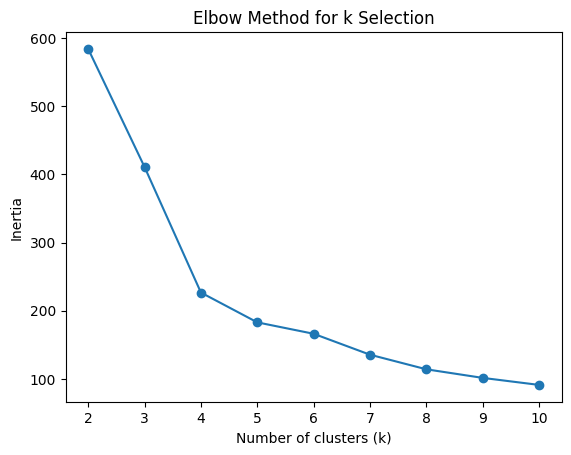

In [80]:
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for k Selection")
plt.show()

## Evaluate how well the clusters are separated using silhoute scores

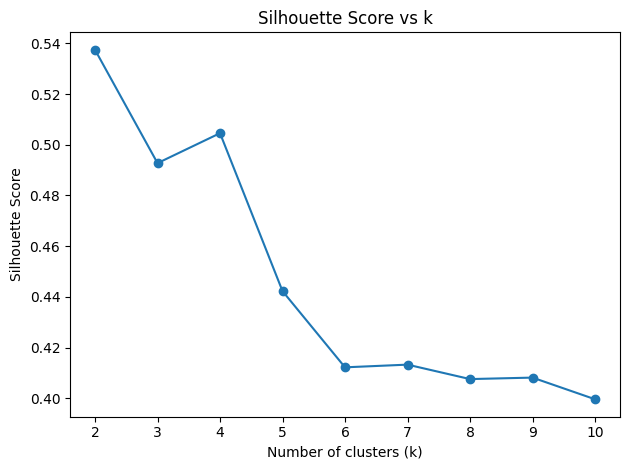

In [81]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

## Perform $k$-means clustering with $k=4$.

In [82]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)
kmeans.fit(X_scaled)

KMeans(n_clusters=4)

## Generate and save the predicted clusters.

In [83]:
df["cluster"] = pd.Categorical(kmeans.predict(X_scaled))

## Examine the first 10 observations.

In [84]:
df["cluster"].head(10)

,cluster
0,0
2,2
3,1
5,1
6,1
7,2
8,1
9,2
10,1
11,1


## Examine the silhouette coefficients of individual samples

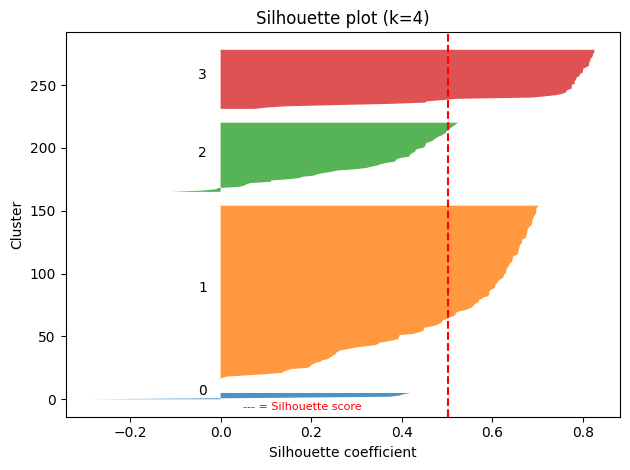

In [85]:
from sklearn.metrics import silhouette_samples

labels = kmeans.labels_
sample_vals = silhouette_samples(X_scaled, labels)

n_clusters = len(np.unique(labels))

y_lower = 0

for i in range(n_clusters):
    vals = sample_vals[labels == i]
    vals.sort()

    size = len(vals)
    y_upper = y_lower + size

    plt.fill_betweenx(range(y_lower, y_upper), 0, vals, alpha=0.8)

    plt.text(-0.05, y_lower + size / 2, str(i))
    y_lower = y_upper + 10

plt.axvline(x=np.mean(sample_vals), color="red", linestyle="--")

plt.text(
    0.05, -10,
    "--- = Silhouette score",
    ha="left",
    va="bottom",
    color="red",
    fontsize=8
)

plt.title(f"Silhouette plot (k={n_clusters})")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Examine the number of observations per cluster.

In [86]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,6
1,139
2,56
3,48


## Visualize the clusters in 2D using Principal Component Analysis.

<Axes: >

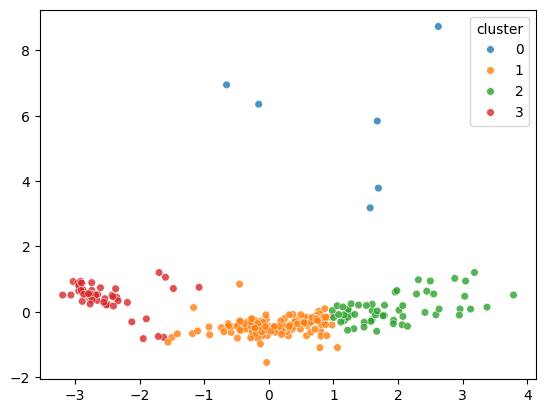

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(
    pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled.columns)
)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster"], s=30, alpha=0.8
)

## Interpret the cluster using cluster means

In [88]:
df.groupby("cluster")[
    ["trips", "med_distance", "med_fare", "med_tip"]
].mean()

/tmp/ipykernel_1765/1273182128.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cluster")[


,trips,med_distance,med_fare,med_tip
cluster,,,,
0,535976.500000,8.561667,55.533333,8.013333
1,25586.280576,4.846655,24.493453,0.026619
2,4431.767857,8.633393,33.749018,0.000000
3,780492.854167,1.908542,13.994792,2.256875


## Visualize the clusters using GeoPandas

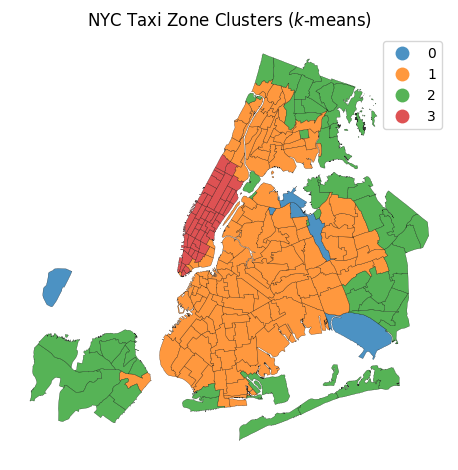

In [89]:
import geopandas as gpd

zones = datadepot.load_zones()
zones = zones.merge(df, on="zone_id", how="left")

from matplotlib.colors import ListedColormap

fig, ax = plt.subplots()

cmap = ListedColormap(plt.get_cmap("tab10").colors[:4])

zones.plot(
    column="cluster", categorical=True, legend=True, cmap=cmap,
    edgecolor="black", linewidth=0.2, alpha=0.8, ax=ax,
)

ax.set_title("NYC Taxi Zone Clusters ($k$-means)")
ax.axis("off")

plt.tight_layout()
plt.show()

## Try it yourself

### Change the number of clusters ($k$) and examine the resulting clusters. Try several values of $k$. Which value seems most appropriate for this dataset?


### Acknowledgement and copyright

© 2026 Jeroen van Raak. Original notebook, code, preprocessing, and visualizations by the author. Based on publicly available NYC Taxi Zones data.